# Лінійна регресія: перенавчання і регуляризація

У цьому завданні ми на прикладах побачимо, як перенавчаються лінійні моделі, розберемо, чому так відбувається, і з'ясуємо, як діагностувати та контролювати перенавчання.

В усіх комірках, де вказаний коментар з інструкціями, потрібно написати код, який виконує ці інструкції. Решту комірок із кодом (без коментарів) треба просто виконати. Крім того, у завданні необхідно відповідати на запитання; відповіді потрібно вписувати після виділеного слова "__Відповідь:__".

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Ми будемо працювати з датасетом __"bikes_rent.csv"__, у якому по днях записані календарна інформація та погодні умови, що характеризують автоматизовані пункти прокату велосипедів, а також кількість прокатів у цей день. Останнє ми будемо передбачати; таким чином, ми будемо розв'язувати завдання регресії.

### Ознайомлення з даними

## Завдання 1

Завантажте датасет за допомогою функції __pandas.read_csv__ у змінну __df__. Виведіть перші 5 рядків, щоб переконатися в коректному зчитуванні даних:

In [3]:
df = pd.read_csv("bikes_rent.csv")
df.head(10)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600
5,1,0,1,0,4,1,1,8.378268,11.66045,51.8261,6.000868,2.682552,1606
6,1,0,1,0,5,1,2,8.057402,10.44195,49.8696,11.304642,5.053483,1510
7,1,0,1,0,6,0,2,6.765000,8.11270,53.5833,17.875868,7.991000,959
8,1,0,1,0,0,0,1,5.671653,5.80875,43.4167,24.250650,10.840702,822
9,1,0,1,0,1,1,1,6.184153,7.54440,48.2917,14.958889,6.687031,1321


Для кожного дня прокату відомі такі ознаки:
* _season_: 1 — весна, 2 — літо, 3 — осінь, 4 — зима
* _yr_: 0 — 2011, 1 — 2012
* _mnth_: від 1 до 12
* _holiday_: 0 — немає свята, 1 — є свято
* _weekday_: від 0 до 6
* _workingday_: 0 — неробочий день, 1 — робочий день
* _weathersit_: оцінка сприятливості погоди від 1 (чистий, ясний день) до 4 (злива, туман)
* _temp_: температура в Цельсіях
* _atemp_: температура за відчуттями в Цельсіях
* _hum_: вологість
* _windspeed(mph)_: швидкість вітру в милях за годину
* _windspeed(ms)_: швидкість вітру в метрах за секунду
* _cnt_: кількість орендованих велосипедів (це цільова ознака, її ми будемо передбачати)

Отже, у нас є речові, бінарні та номінальні (порядкові) ознаки, і з усіма з них можна працювати як з речовими. З номінальними ознаками теж можна працювати як з речовими, тому що на них заданий порядок. Давайте подивимося на графіках, як цільова ознака залежить від решти.

Побудуйте графіки залежностей атрибутів від кількості поїздок. Іншими словами, вам потрібно побудувати 12 графіків. На кожному має бути зображена залежність чергового атрибута від змінної **cnt**.

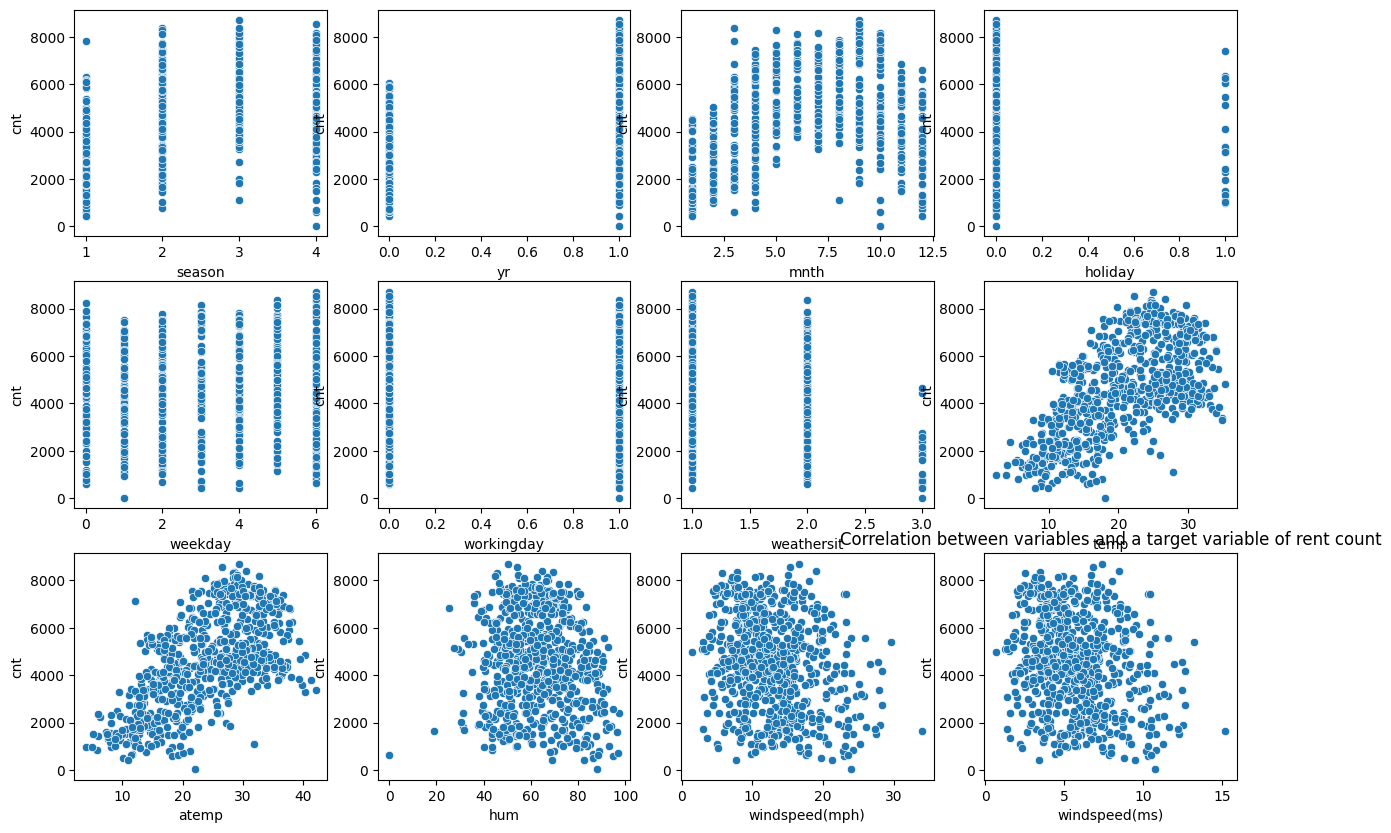

In [4]:
fig, axs = plt.subplots(3, 4, figsize=(15, 10))

sns.scatterplot(data=df, x="season", y="cnt", ax=axs[0, 0])
sns.scatterplot(data=df, x="yr", y="cnt", ax=axs[0, 1])
sns.scatterplot(data=df, x="mnth", y="cnt", ax=axs[0, 2])
sns.scatterplot(data=df, x="holiday", y="cnt", ax=axs[0, 3])
sns.scatterplot(data=df, x="weekday", y="cnt", ax=axs[1, 0])
sns.scatterplot(data=df, x="workingday", y="cnt", ax=axs[1, 1])
sns.scatterplot(data=df, x="weathersit", y="cnt", ax=axs[1, 2])
sns.scatterplot(data=df, x="temp", y="cnt", ax=axs[1, 3])
sns.scatterplot(data=df, x="atemp", y="cnt", ax=axs[2, 0])
sns.scatterplot(data=df, x="hum", y="cnt", ax=axs[2, 1])
sns.scatterplot(data=df, x="windspeed(mph)", y="cnt", ax=axs[2, 2])
sns.scatterplot(data=df, x="windspeed(ms)", y="cnt", ax=axs[2, 3])
plt.title("Correlation between variables and a target variable of rent count")

plt.show()

__Запитання:__
1. Яким є характер залежності кількості прокатів від місяця?
1. Вкажіть одну або дві ознаки, від яких кількість прокатів скоріше за все залежить лінійно.

### Відповіді
1. Як відображено на графіку кулькість випозичень починає стрімко підійматися в гору, і починає зниження приблизно на кінці Серпня.

2. Лінійну залежнітсь можна відстежити у таких ознак як температура, як за відчуттям так і фактичною, вологість повітря ті швидкість вітру.

## Завдання 2

Давайте більш строго оцінимо рівень лінійної залежності між ознаками та цільовою змінною. Гарною мірою лінійної залежності між двома векторами є кореляція Пірсона. Нам уже доводилося мати з нею справу раніше. Для її обчислення в pandas можна використовувати методи датафрейму: corr і corrwith.

Порахуйте кореляції всіх ознак, окрім останньої, з останньою за допомогою методу `corrwith`.

In [5]:
correlations = df.corrwith(df["cnt"])[:-1]
correlations

season            0.406100
yr                0.566710
mnth              0.279977
holiday          -0.068348
weekday           0.067443
workingday        0.061156
weathersit       -0.297391
temp              0.627494
atemp             0.631066
hum              -0.100659
windspeed(mph)   -0.234545
windspeed(ms)    -0.234545
dtype: float64

У вибірці є ознаки, що корелюють із цільовою, а отже, завдання можна розв'язувати лінійними методами.

За графіками видно, що деякі ознаки схожі між собою. Тому давайте також порахуємо кореляції між речовими ознаками.

## Завдання 3

Порахуйте попарні кореляції між ознаками temp, atemp, hum, windspeed(mph), windspeed(ms) і cnt
за допомогою методу corr:

In [6]:
temp_corr = df['cnt'].corr(df['temp'])
atemp_corr = df['cnt'].corr(df['atemp'])
hum_corr = df['cnt'].corr(df['hum'])
windspeed_mph_corr = df['cnt'].corr(df['windspeed(mph)'])
windspeed_ms_corr = df['cnt'].corr(df['windspeed(ms)'])

print("Temperature(actual): ",temp_corr)
print("Temperature(feeling): ",atemp_corr)
print("Humidity: ", hum_corr)
print("Windspeed(in miles per hour): ",windspeed_mph_corr)
print("Windspeed(in meters per second): ",windspeed_ms_corr)

Temperature(actual):  0.6274940090334922
Temperature(feeling):  0.6310656998491813
Humidity:  -0.1006585621371552
Windspeed(in miles per hour):  -0.23454499742167004
Windspeed(in meters per second):  -0.2345449974216893


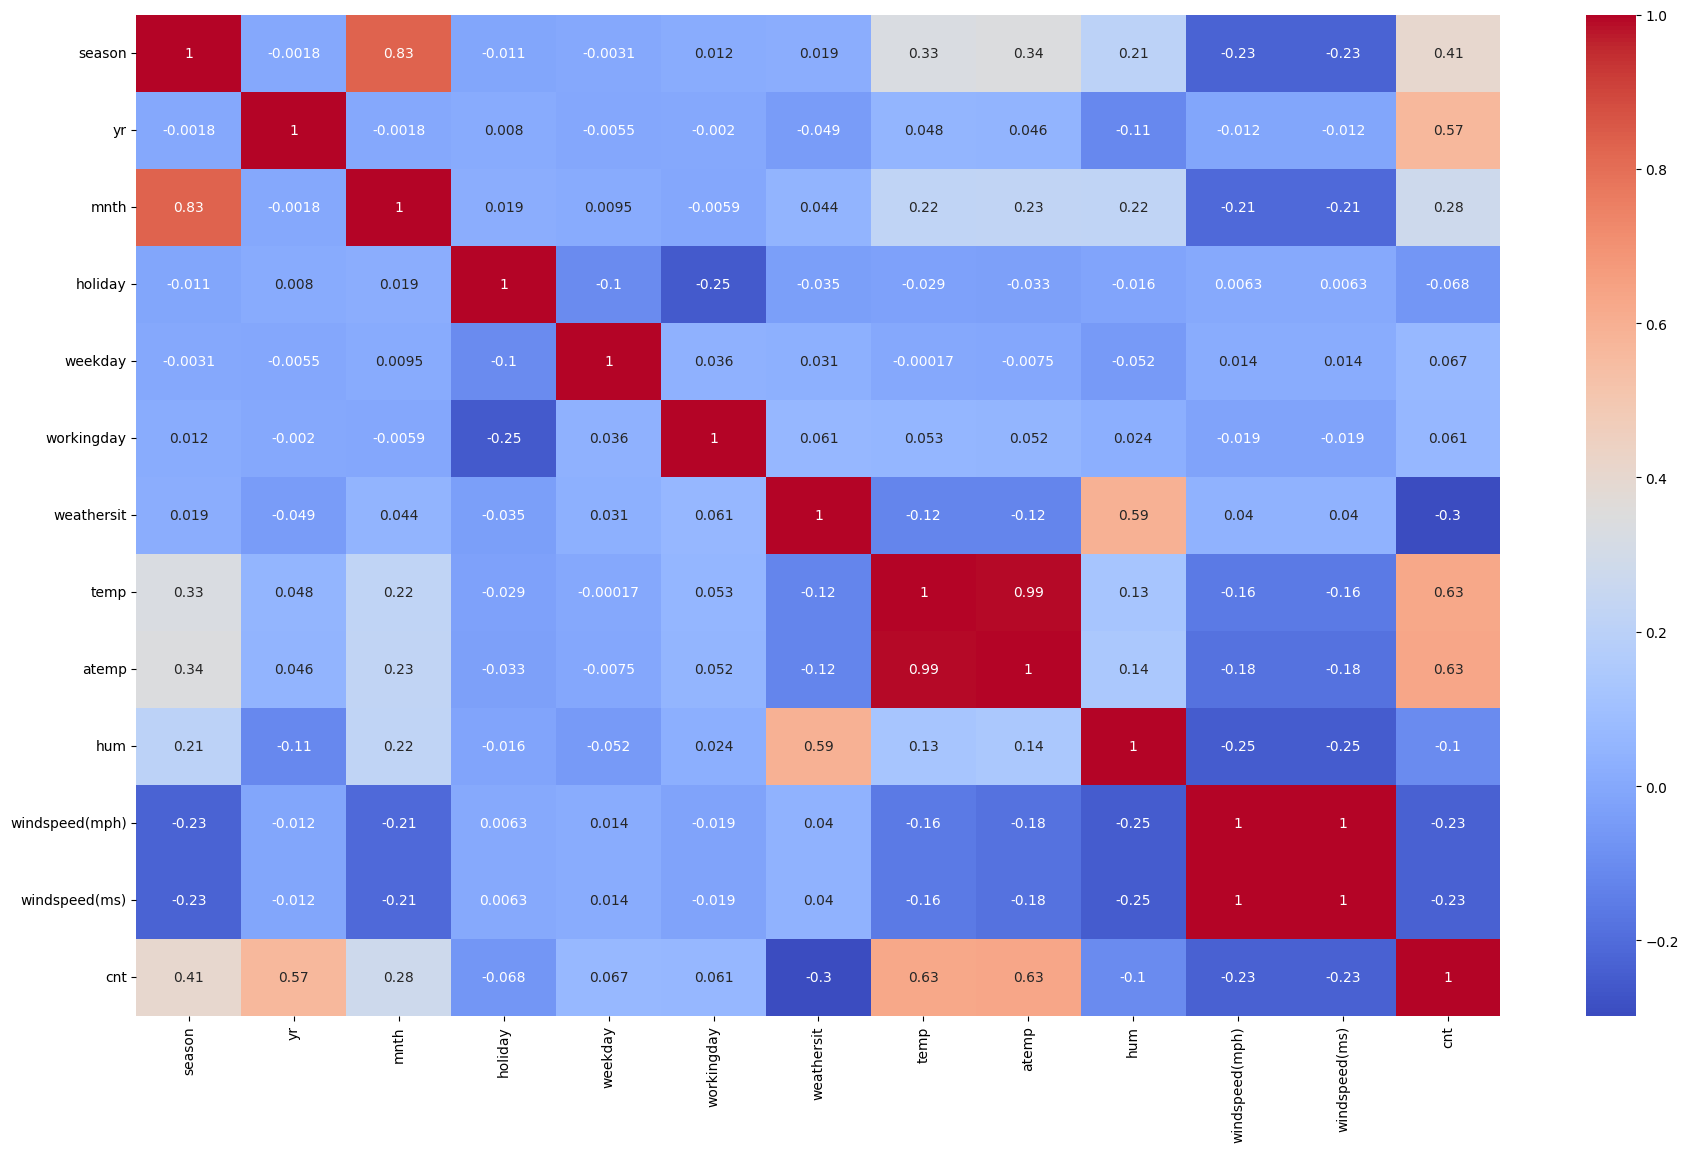

In [7]:
mtx = df.corr()

plt.figure(figsize=(22, 13))
sns.heatmap(mtx, cmap='coolwarm', annot=True)

plt.show()

На діагоналях, як і належить, стоять одиниці. Однак у матриці є ще дві пари сильно корелюючих стовпців: temp і atemp (корелюють за своєю природою) і два windspeed (тому що це просто переведення одних одиниць в інші). Далі ми побачимо, що цей факт негативно позначається на навчанні лінійної моделі.

Насамкінець подивимося середні ознак (метод mean), щоб оцінити масштаб ознак і частки 1 у бінарних ознак.

## Завдання 4

Виведіть середні ознак.

In [8]:
for col in df.columns:
    print(f"{col, df[col].mean()}")

('season', np.float64(2.496580027359781))
('yr', np.float64(0.5006839945280438))
('mnth', np.float64(6.519835841313269))
('holiday', np.float64(0.028727770177838577))
('weekday', np.float64(2.997264021887825))
('workingday', np.float64(0.6839945280437757))
('weathersit', np.float64(1.3953488372093024))
('temp', np.float64(20.31077632886457))
('atemp', np.float64(23.717699432284544))
('hum', np.float64(62.78940629274965))
('windspeed(mph)', np.float64(12.762576179069768))
('windspeed(ms)', np.float64(5.705219570438215))
('cnt', np.float64(4504.3488372093025))


Ознаки мають різний масштаб, отже, для подальшої роботи нам краще нормувати матрицю об'єкти-ознаки.

### Проблема перша: колінеарні ознаки

Отже, у наших даних одна ознака дублює іншу, і є ще дві дуже схожі. Звичайно, ми могли б одразу видалити дублікати, але давайте подивимося, як відбувалося б навчання моделі, якби ми не помітили цю проблему.

Для початку проведемо масштабування, або стандартизацію ознак: з кожної ознаки віднімемо її середнє і поділимо на стандартне відхилення. Це можна зробити за допомогою методу scale.

Крім того, необхідно перемішати вибірку, це буде потрібно для крос-валідації.

In [9]:
from sklearn.preprocessing import scale
from sklearn.utils import shuffle

In [10]:
df_shuffled = shuffle(df, random_state=42)
X = scale(df_shuffled[df_shuffled.columns[:-1]])
y = df_shuffled["cnt"]

Давайте навчимо лінійну регресію на наших даних і подивимося на ваги ознак.

In [11]:
from sklearn.linear_model import LinearRegression

## Завдання 5

Створіть об'єкт лінійного регресора, навчіть його на всіх даних і виведіть ваги моделі (ваги зберігаються у змінній `coef_` класу регресора). Можна виводити пари (назва ознаки, вага), скориставшись функцією `zip`, вбудованою в мову python. Назви ознак зберігаються у змінній `df.columns`.


In [12]:
model_linear = LinearRegression().fit(X, y)

for coefficient in model_linear.coef_:
    print(coefficient)

for factor in zip(df.columns):
    print(factor)

570.863641661725
1021.9604245185086
-141.3006331900142
-86.75760471139698
137.2272583151452
56.38980357474366
-330.2271825899341
367.4799030832653
585.5521797658965
-145.6155228231448
12454356291009.727
-12454356291208.188
('season',)
('yr',)
('mnth',)
('holiday',)
('weekday',)
('workingday',)
('weathersit',)
('temp',)
('atemp',)
('hum',)
('windspeed(mph)',)
('windspeed(ms)',)
('cnt',)


Ми бачимо, що ваги при лінійно-залежних ознаках за модулем значно більші, ніж при інших ознаках. Щоб зрозуміти, чому так сталося, згадаємо аналітичну формулу, за якою обчислюються ваги лінійної моделі в методі найменших квадратів:

$$w = (X^TX)^{-1} X^T y$$

Якщо в $X$ є колінеарні (лінійно-залежні) стовпці, матриця $X^TX$ стає виродженою, і формула перестає бути коректною. Чим більш залежні ознаки, тим менший визначник цієї матриці й тим гірша апроксимація $Xw \approx y$. Таку ситуацію називають _проблемою мультиколінеарності_.

З парою (temp, atemp) трохи менше корелюючих змінних такого не сталося, однак на практиці завжди варто уважно стежити за коефіцієнтами при схожих ознаках.

Для того щоб розв'язати проблему мультиколінеарності, потрібно скористатися регуляризатором. До оптимізуючого функціоналу додають $L_1$ або $L_2$ норму ваг, помножену на коефіцієнт регуляризації $\alpha$. У першому випадку метод називається Lasso, а у другому — Ridge.

### Завдання 6
Давайте спробуємо навчити лінійні моделі з $L_1$ і $L_2$-регуляризацією, а далі порівняємо їхні ваги. Навчіть регресори Ridge і Lasso з параметрами за замовчуванням і переконайтеся, що проблема з вагами вирішилась.

Навчіть лінійну модель з $L_1$-регуляризацією (клас Lasso) і виведіть ваги.

In [13]:
# Put your code here
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=1)
lasso.fit(X_scaled, y)

print(lasso.coef_)
print(lasso.__dict__)

[ 5.60241616e+02  1.01946349e+03 -1.28730627e+02 -8.61527813e+01
  1.37347894e+02  5.52123706e+01 -3.32369857e+02  3.76363236e+02
  5.76530794e+02 -1.44129155e+02 -1.97139689e+02 -2.80467993e-08]
{'alpha': 1, 'l1_ratio': 1.0, 'fit_intercept': True, 'precompute': False, 'max_iter': 1000, 'copy_X': True, 'tol': 0.0001, 'warm_start': False, 'positive': False, 'random_state': None, 'selection': 'cyclic', 'n_features_in_': 12, 'n_iter_': 286, 'coef_': array([ 5.60241616e+02,  1.01946349e+03, -1.28730627e+02, -8.61527813e+01,
        1.37347894e+02,  5.52123706e+01, -3.32369857e+02,  3.76363236e+02,
        5.76530794e+02, -1.44129155e+02, -1.97139689e+02, -2.80467993e-08]), 'dual_gap_': np.float64(39.8450806804623), 'intercept_': np.float64(4504.3488372093025)}


Навчіть лінійну модель з $L_2$-регуляризацією (клас Ridge) і виведіть ваги.

In [14]:
# Put your code here
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)

print(ridge.coef_)
print(ridge.__dict__)

[ 563.06457225 1018.94837879 -131.87332028  -86.746098    138.00511118
   55.90311038 -332.3497885   386.45788919  566.34704706 -145.0713273
  -99.25944108  -99.25944115]
{'alpha': 1.0, 'fit_intercept': True, 'copy_X': True, 'max_iter': None, 'tol': 0.0001, 'solver': 'auto', 'positive': False, 'random_state': None, 'n_features_in_': 12, 'coef_': array([ 563.06457225, 1018.94837879, -131.87332028,  -86.746098  ,
        138.00511118,   55.90311038, -332.3497885 ,  386.45788919,
        566.34704706, -145.0713273 ,  -99.25944108,  -99.25944115]), 'n_iter_': None, 'solver_': 'cholesky', 'intercept_': np.float64(4504.3488372093025)}


### Завдання 7

На відміну від $L_2$-регуляризації, $L_1$ обнуляє ваги при деяких ознаках. Давайте поспостерігаємо, як змінюються ваги зі збільшенням коефіцієнта регуляризації $\alpha$.

Для кожного значення коефіцієнта з `alphas` навчіть регресор `Lasso` і запишіть ваги у список `coefs_lasso`, а потім навчіть `Ridge` і запишіть ваги у список`coefs_ridge`. Конвертуйте отримані списки в `np.array`.

In [15]:
alphas = np.float64(np.arange(1, 500, 50))

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha).fit(X_scaled, y)
    ridge = Ridge(alpha=alpha).fit(X_scaled, y)
    
    coefs_lasso.append(lasso.coef_)
    coefs_ridge.append(ridge.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

print("Lasso coefficients: ",coefs_lasso)
print("Ridge coefficients: ",coefs_ridge)

Lasso coefficients:  [[ 5.60241616e+02  1.01946349e+03 -1.28730627e+02 -8.61527813e+01
   1.37347894e+02  5.52123706e+01 -3.32369857e+02  3.76363236e+02
   5.76530794e+02 -1.44129155e+02 -1.97139689e+02 -2.80467993e-08]
 [ 4.10969632e+02  9.77019409e+02 -0.00000000e+00 -5.34489688e+01
   9.19434374e+01  1.75372118e+01 -3.18125568e+02  3.22829934e+02
   6.10031512e+02 -9.10689615e+01 -1.45066095e+02 -2.29856559e-08]
 [ 3.70077089e+02  9.35945490e+02  0.00000000e+00 -1.21619360e+01
   4.88886342e+01  0.00000000e+00 -3.08805664e+02  2.69417263e+02
   6.32502623e+02 -2.75042876e+01 -9.37749037e+01 -2.41634652e-08]
 [ 3.32835717e+02  8.91870058e+02  0.00000000e+00 -0.00000000e+00
   0.00000000e+00  0.00000000e+00 -2.79616688e+02  2.11052030e+02
   6.62920880e+02 -0.00000000e+00 -5.01551472e+01 -2.62785691e-08]
 [ 2.98134448e+02  8.45652857e+02  0.00000000e+00 -0.00000000e+00
   0.00000000e+00  0.00000000e+00 -2.35571345e+02  1.24144807e+02
   7.25379483e+02 -0.00000000e+00 -1.26461769e+01 -

Проаналізуйте динаміку ваг при збільшенні параметра регуляризації:

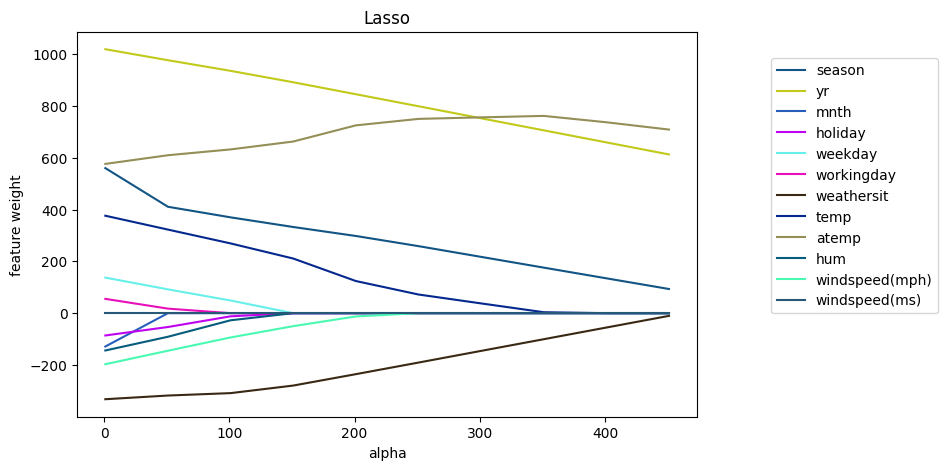

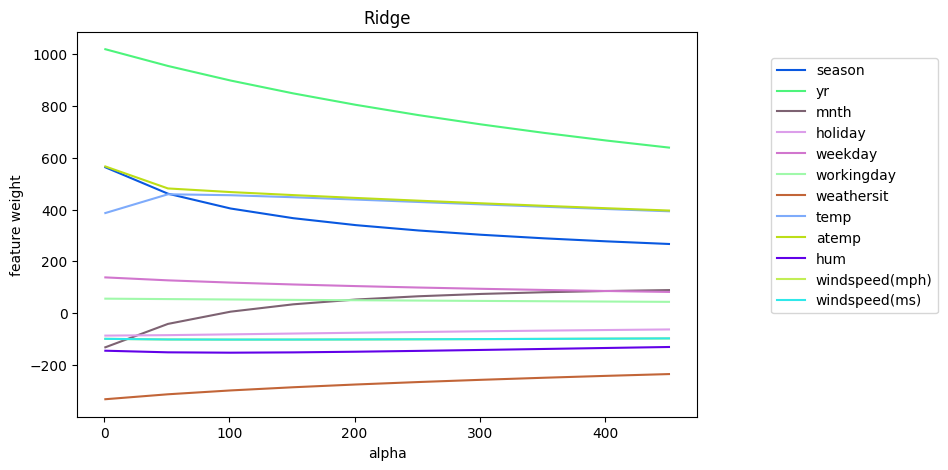

In [16]:
plt.figure(figsize=(8, 5))

for coef, feature in zip(coefs_lasso.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))

for coef, feature in zip(coefs_ridge.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

plt.show()

Проаналізуйте графіки та дайте відповіді на такі запитання.

1. Який регуляризатор (Ridge або Lasso) агресивніше зменшує ваги при одному й тому самому alpha?
1. Що станеться з вагами Lasso, якщо alpha зробити дуже великим? Поясніть, чому так відбувається.
1. Чи можна стверджувати, що `Lasso` виключає одну з ознак `windspeed` при будь-якому значенні `alpha > 0`? А Ridge? Вважається, що регуляризатор виключає ознаку, якщо коефіцієнт при ньому менший $10^{-3}$.
1. Який із регуляризаторів підійде для відбору неінформативних ознак?

Відповіді:
1. Lasso зменшує ваги набагато аггресивніше, що можна побачити по набагато куртіших схилах ніж у Ridge
1. Чи більше альфа тим міцніше буде регуляризація кари(penalty), що приводить то більш аггрессивного вибори фич, що в свою чергу призводить до анульовання деяяких фич.
1. Ознака winspeed не включається при значенні альфа>0, що можна побачити на графіку. Так само з классифікатором Ridge, пр альфа > 0 ці однаки не включаються.
1. Ridge, оскільки він краще впорається з не циферними ознаками.

### Завдання 8

Далі будемо працювати з `Lasso`.

Отже, ми бачимо, що при зміні alpha модель по-різному підбирає коефіцієнти ознак. Нам потрібно вибрати найкраще alpha.

Для цього, по-перше, нам потрібна метрика якості. Будемо використовувати як метрику сам оптимізований функціонал методу найменших квадратів, тобто `Mean Square Error`.

По-друге, потрібно зрозуміти, на яких даних цю метрику рахувати. Не можна вибирати `alpha` за значенням MSE на навчальній вибірці, тому що тоді ми не зможемо оцінити, як модель буде робити передбачення на нових для неї даних. Якщо ми виберемо одне розбиття вибірки на навчальну та тестову (це називається holdout), то налаштуємося на конкретні "нові" дані, і знову можемо перенавчитися. Тому будемо робити декілька розбиттів вибірки, на кожному пробувати різні значення alpha, а потім усереднювати MSE. Найзручніше робити такі розбиття крос-валідацією, тобто розділити вибірку на $K$ частин, і кожного разу брати одну з них як тестову, а з блоків, що залишилися, складати навчальну вибірку.

Робити крос-валідацію для регресії в sklearn зовсім просто: для цього є спеціальний регресор, __LassoCV__, який бере на вхід список із alpha і для кожного з них обчислює MSE на крос-валідації. Після навчання (якщо залишити параметр cv=3 за замовчуванням) регресор буде містити змінну __mse\_path\___, матрицю розміру len(alpha) x k, k = 3 (число блоків у крос-валідації), що містить значення MSE на тесті для відповідних запусків. Крім того, у змінній alpha\_ буде зберігатися вибране значення параметра регуляризації, а в coef\_, традиційно, навчені ваги, що відповідають цьому alpha_.

Зверніть увагу, що регресор може змінювати порядок, у якому він проходить по alphas; для зіставлення з матрицею MSE краще використовувати змінну регресора alphas_.

Навчіть регресор `LassoCV` на всіх параметрах регуляризації з alpha. Побудуйте графік _усередненого_ за рядками `MSE` в залежності від `alpha` (використовуйте для цього функцію `create_plot`).

Виведіть вибране `alpha`, а також пари "ознака-коефіцієнт" для навченого вектора коефіцієнтів.

In [17]:
def create_plot(data, title, xlabel, ylabel, figsize=None):
    size = figsize or (15, 5)
    plt.figure(figsize=size)

    x = map(lambda e: e[0], data)
    y = map(lambda e: e[1], data)
    plt.plot(x, y)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid()
    plt.show()

Alphas: [96 91 86 81 76 71 66 61 56 51 46 41 36 31 26 21 16 11  6  1]
Avg MSE: [851990.72268622 846392.15883646 840822.79452996 835574.34242349
 830286.6292665  825198.48200101 820159.70188599 815491.23843715
 811192.90438185 807264.70262735 803575.5866472  800211.24746208
 797217.56999301 794594.56066723 792342.19576555 789464.66320254
 786750.84083864 783634.3772912  781531.09081992 785055.146787  ]


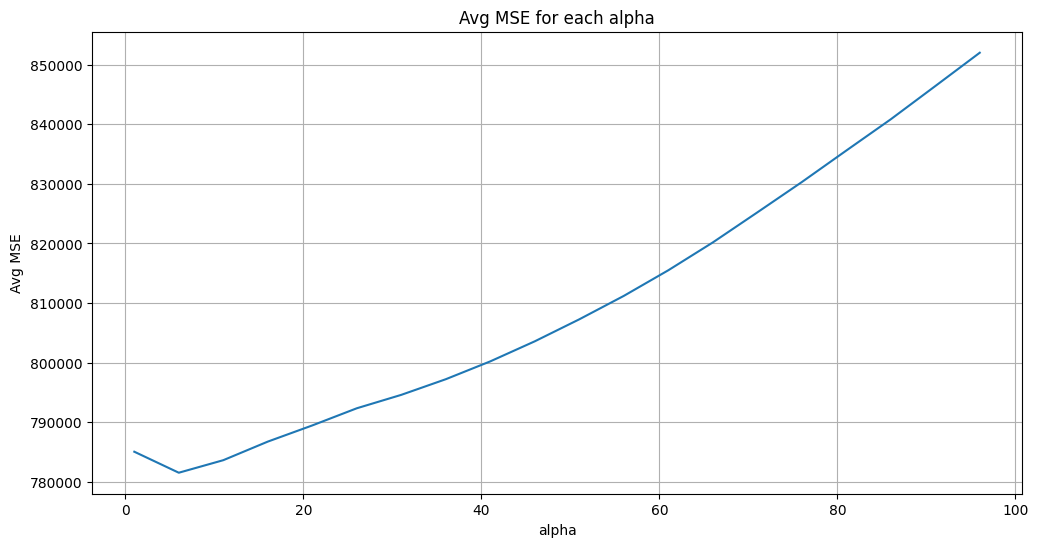

In [18]:
from sklearn.linear_model import LassoCV

alphas = np.arange(1, 100, 5)

regressor = LassoCV(cv=3, random_state=0, alphas=alphas).fit(X_scaled, y)

print(f"Alphas: {regressor.alphas_}")
mse = regressor.mse_path_.mean(axis=1)
print(f"Avg MSE: {mse}")

#visualize the MSE for each alpha
plt.figure(figsize=(12, 6))
plt.plot(regressor.alphas_, mse)
plt.title("Avg MSE for each alpha")
plt.xlabel("alpha")
plt.ylabel("Avg MSE")
plt.grid()
plt.show()

Отже, ми вибрали певний параметр регуляризації. Давайте подивимося, які б ми вибирали alpha, якби ділили вибірку лише один раз на навчальну та тестову, тобто розглянемо траєкторії MSE, що відповідають окремим блокам вибірки.

### Завдання 9

Виведіть значення `alpha`, що відповідають мінімумам `MSE` на кожному розбитті (тобто за стовпцями).
На трьох окремих графіках візуалізуйте стовпці `mse_path_`.


In [23]:
for alpha, min_mse in zip(regressor.alphas_, mse):
    print(f"Alpha: {alpha}, Avg MSE: {min_mse}")

Alpha: 96, Avg MSE: 851990.7226862218
Alpha: 91, Avg MSE: 846392.1588364625
Alpha: 86, Avg MSE: 840822.7945299604
Alpha: 81, Avg MSE: 835574.3424234892
Alpha: 76, Avg MSE: 830286.6292664971
Alpha: 71, Avg MSE: 825198.4820010137
Alpha: 66, Avg MSE: 820159.7018859917
Alpha: 61, Avg MSE: 815491.2384371454
Alpha: 56, Avg MSE: 811192.904381845
Alpha: 51, Avg MSE: 807264.7026273534
Alpha: 46, Avg MSE: 803575.5866471967
Alpha: 41, Avg MSE: 800211.2474620751
Alpha: 36, Avg MSE: 797217.5699930098
Alpha: 31, Avg MSE: 794594.5606672269
Alpha: 26, Avg MSE: 792342.1957655508
Alpha: 21, Avg MSE: 789464.6632025437
Alpha: 16, Avg MSE: 786750.8408386441
Alpha: 11, Avg MSE: 783634.3772912038
Alpha: 6, Avg MSE: 781531.0908199241
Alpha: 1, Avg MSE: 785055.1467870023


На кожному розбитті оптимальне значення `alpha` своє, і йому відповідає велике MSE на інших розбиттях. Виходить, що ми налаштовуємося на конкретні навчальні та контрольні вибірки. При виборі `alpha` на крос-валідації ми вибираємо дещо "середнє", що даватиме прийнятне значення метрики на різних розбиттях вибірки.

### Завдання 10

Нарешті, як прийнято в аналізі даних, давайте проінтерпретуємо результат. Дайте відповіді на наступні запитання.

#### Запитання 1

В останній навченій моделі виберіть 4 ознаки з найбільшими (позитивними) коефіцієнтами (і випишіть їх), подивіться на візуалізації залежностей `cnt` від цих ознак, які ми зображали у блоці "Ознайомлення з даними". Чи видно зростаючу лінійну залежність `cnt` від цих ознак за графіками? Чи логічно стверджувати (виходячи зі здорового глузду), що чим більше значення цих ознак, тим більше людей захочуть взяти велосипеди?

__Відповідь:__

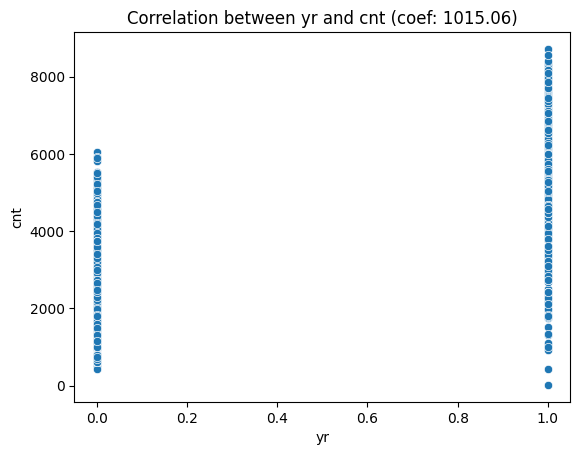

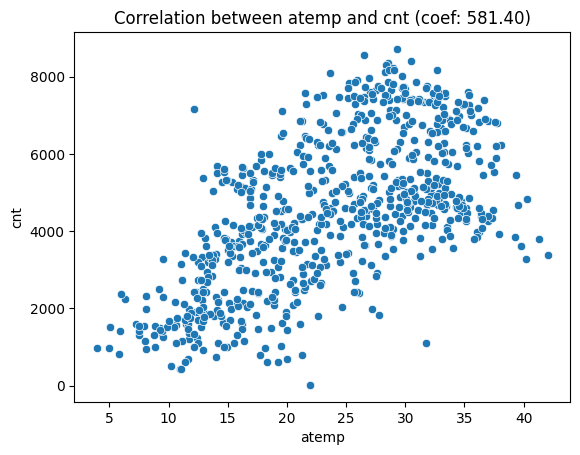

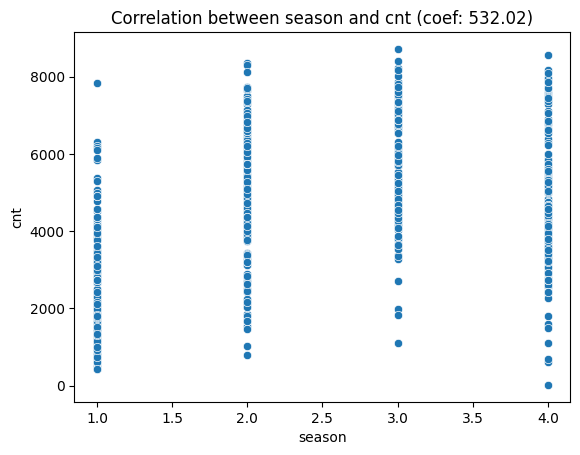

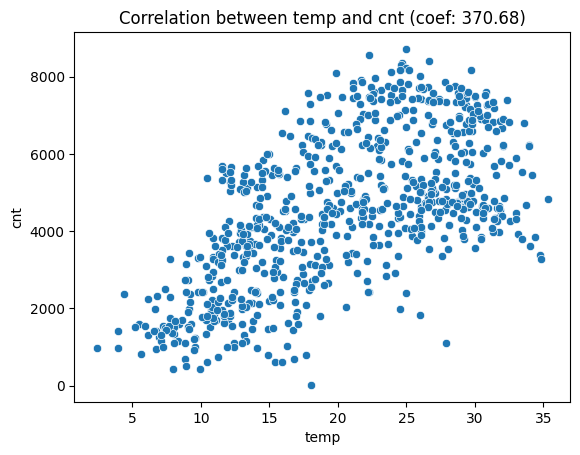

In [ ]:
#visualize the correlations between "cnt" and 4 features that the highest coefficients in the Lasso regression
features = df.columns[:-1]
coef_lasso = regressor.coef_
feature_coef_pairs = list(zip(features, coef_lasso))
feature_coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
top_features = feature_coef_pairs[:4]

for feature, coef in top_features:
    sns.scatterplot(data=df, x=feature, y="cnt")
    plt.title(f"Correlation between {feature} and cnt (coef: {coef:.2f})")
    plt.show()

Відповідь: лінійна азлежність прослідковується з такими фічами як temp i atemp

#### Запитання 2

Виберіть 3 ознаки з найбільшими за модулем негативними коефіцієнтами (і випишіть їх), подивіться на відповідні візуалізації. Чи видно лінійну залежність, що зменшується? Чи логічно стверджувати, що чим більша величина цих ознак, тим менше людей захочуть взяти велосипеди?

__Відповідь:__

Top 3 features with highest negative coefficients in Lasso regression:
weathersit: -330.56
windspeed(mph): -191.77
hum: -140.01


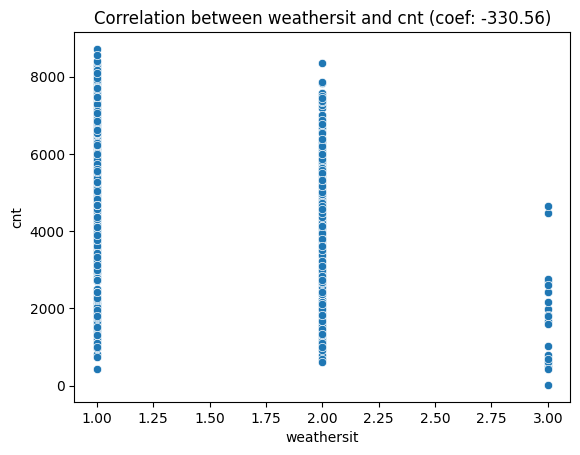

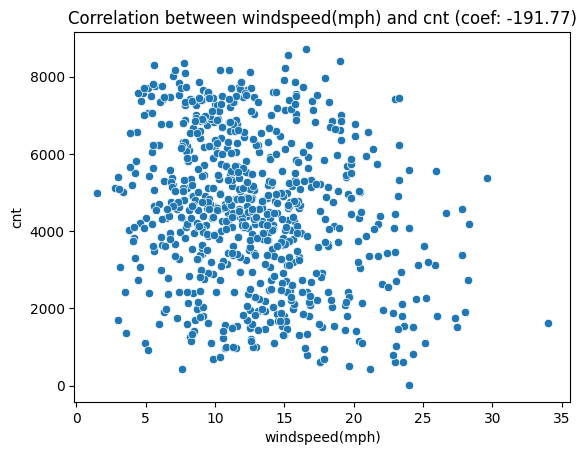

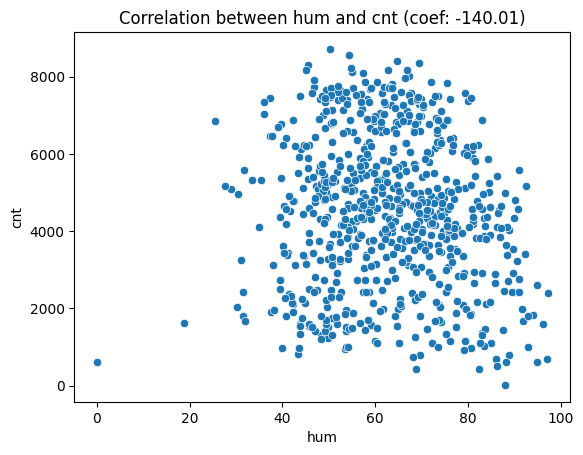

In [ ]:
#choose three features with hhighest negetive coeefficients in the Lasso regression
negative_feature_coef_pairs = [pair for pair in feature_coef_pairs if pair[1] < 0]
negative_feature_coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
top_negative_features = negative_feature_coef_pairs[:3]
print("Top 3 features with highest negative coefficients in Lasso regression:")

for feature, coef in top_negative_features:
    print(f"{feature}: {coef:.2f}")

#visualzie
for feature, coef in top_negative_features:
    sns.scatterplot(data=df, x=feature, y="cnt")
    plt.title(f"Correlation between {feature} and cnt (coef: {coef:.2f})")
    plt.show()

print("Linear dependency between windspeed and humidity")

Відповідь: підвищенна швидкість вітру негативно впливає на кількість випозиченних велосипедів.

Лінійна залежність прослідковується між швидкістью вітру та вологістю повітря.

#### Запитання 3

Випишіть ознаки з коефіцієнтами, близькими до нуля (< 1e-3). Як ви думаєте, чому модель виключила їх із моделі (знову подивіться на графіки)? Чи правда, що вони ніяк не впливають на попит на велосипеди?

__Відповідь:__

In [30]:
#coefficients of features that approach zero
near_zero_coefs = [pair for pair in feature_coef_pairs if abs(pair[1]) < 1e-3]
print("Features with coefficients close to zero in Lasso regression:")
for feature, coef in near_zero_coefs:
    print(f"{feature}: {coef}")

Features with coefficients close to zero in Lasso regression:
windspeed(ms): -2.6850683617239326e-08


Відповідь: швидкість вітру може мати вплив на кількість, але через те що лассо побудований на l1 классифікаторі, його мала вартість призводить до того що ця ознака викидується з цього классифікатора.

### Висновок
Отже, ми подивилися, як можна стежити за адекватністю лінійної моделі, як відбирати ознаки і як грамотно, за можливості не налаштовуючись на якусь конкретну порцію даних, підбирати коефіцієнт регуляризації.

Варто зазначити, що за допомогою крос-валідації зручно підбирати лише невелику кількість параметрів. (1, 2, максимум 3), тому що для кожної допустимої їх комбінації нам доводиться декілька разів навчати модель. Такий процес займає багато часу, особливо якщо треба навчатися на великих обсягах даних.